- `Acesso aos dados`: [MCD19A2.061: Terra & Aqua MAIAC Land Aerosol Optical Depth Daily 1km ](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD19A2_GRANULES)
- `Período dos dados`: 2000-02-24T00:00:00Z–2024-05-16T23:55:00Z
- `Resolução espacial`: 1000 metros
- `Resolução temporal`: diária
- `Valores`: min=-0,1 e max=8,0
- `Variável utilizada`: Aerosol optical depth over land retrieved in the MODIS Green band (0.55 μm)
- `Código realizado por`: Enrique V. Mattos - 13/04/2025

In [ ]:
# instala biblioteca
!pip install -q xee==0.0.24

# importa bibliotecas
import ee
import geemap
import xee
import xarray as xr

# inicializando GEE
geemap.ee_initialize(project='ee-enrique',
                     opt_url='https://earthengine-highvolume.googleapis.com')

# shapefile
estado_sp = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM1_NAME', 'Sao Paulo'))

# carrega os dados
AOD_2025 = ee.ImageCollection('MODIS/061/MCD19A2_GRANULES') \
             .filterBounds(estado_sp) \
             .filterDate('2024-01-01', '2025-01-01') \
             .select('Optical_Depth_055') \
             .mean() \
             .multiply(0.001) \
             .clip(estado_sp)

# converte para xarray Dataset
ds = xr.open_dataset(AOD_2025,
                     engine = 'ee',
                     crs = 'EPSG:4326',
                     scale = 0.20,
                     geometry = estado_sp.geometry())

# reorganiza dimensões
ds = ds.transpose("time", "lat", "lon")

# mostra os dados
ds

# Preparando o ambiente

In [ ]:
# instalações
!pip install -q ultraplot cartopy salem rasterio pyproj geopandas

#============================================================================================#
#                                        GEE
#============================================================================================#
# instala bibliotecas
!pip install -q xee==0.0.24

# importa bibliotecas
import ee
import geemap
import xee

# inicializando GEE
geemap.ee_initialize(project='ee-enrique',
                     opt_url='https://earthengine-highvolume.googleapis.com')
#============================================================================================#

# importa bibliotecas
import xarray as xr
import os
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import cartopy, cartopy.crs as ccrs
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# monta drive
from google.colab import drive
drive.mount('/content/drive')

# diretório raiz
dir = '/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes'

# diretório de saida dos arquivos netcdf
dir_output_netcdf = f'{dir}/output/05_netcdf_aod_550nm_por_ano'

# diretório de saida dos arquivos de figura
dir_output_figura = f'{dir}/output'

# cria pasta de saída dos netcdf
os.makedirs(dir_output_netcdf, exist_ok=True)

# limites do Brasil
lonmin_BR, lonmax_BR, latmin_BR, latmax_BR = -75.0, -33.0, -35.0, 7.0

# limites de MG
lonmin_MG, lonmax_MG, latmin_MG, latmax_MG = -52., -39., -23., -14.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.7 MB/s eta 0:00:00
Mounted at /content/drive


# Mapa no GEE

## 1 DIA - BRASIL: 23/ago/2024

In [ ]:
# importa bibliotecas
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# shapefiles
brasil = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Brazil'))

# carrega os dados. 1 DIA - BRASIL: 23/ago/2024
umdia_br = ee.ImageCollection('MODIS/061/MCD19A2_GRANULES') \
             .filterDate('2024-08-23', '2024-08-24') \
             .select('Optical_Depth_055') \
             .filterBounds(brasil) \
             .map(lambda img: img.multiply(0.001).copyProperties(img, img.propertyNames()))

# transforma a data para o formato "ano-mes-dia hora:minuto" e extrai os valores
datas = umdia_br.map(lambda img: img.set( {"DATE": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd hh:mm")}))

# agrega as informações
agrega = (datas.aggregate_array("DATE").getInfo())

# mostra na tela
df_umdia_br = pd.DataFrame(agrega)
display(df_umdia_br)

# cria a moldura do mapa
Map = geemap.Map()

# centraliza o mapa na região
Map.centerObject(brasil, zoom=4)

# parâmetros de visualização
# converte matplotlib colormap para uma lista de cores hexadecimais
cmap = cm.get_cmap('RdBu_r', 256) # Get the colormap with 256 colors
hex_colors = [mcolors.rgb2hex(cmap(i)) for i in range(cmap.N)]
vis = {'min': 0, 'max': 1, 'palette': hex_colors}

# plota mapa
Map.addLayer(umdia_br.max().clip(brasil), vis, 'AOD MODIS Green band (0.55 μm)')

# contorno da região
style1 = {'color': 'red', 'fillColor': '00000000'}
Map.addLayer(brasil.style(**style1), {}, 'BRASIL')

# barra de cores
Map.add_colorbar_branca(colors=vis['palette'], vmin=vis['min'], vmax=vis['max'], layer_name='AOD MODIS Green band (0.55 μm)')

# exibe na tela
Map

## 1 DIA - SP: 23/ago/2024

In [ ]:
# importa bibliotecas
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# shapefile
estado_sp = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM1_NAME', 'Sao Paulo'))

# carrega os dados. 1 DIA - SP: 23/ago/2024
umdia_sp = ee.ImageCollection('MODIS/061/MCD19A2_GRANULES') \
             .filterDate('2024-08-23', '2024-08-24') \
             .select('Optical_Depth_055') \
             .filterBounds(estado_sp)  \
             .map(lambda img: img.multiply(0.001).copyProperties(img, img.propertyNames()))

# transforma a data para o formato "ano-mes-dia hora:minuto" e extrai os valores
datas = umdia_sp.map(lambda img: img.set( {"DATE": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd hh:mm")}))

# agrega as informações
agrega = (datas.aggregate_array("DATE").getInfo())

# mostra na tela
df_umdia_sp = pd.DataFrame(agrega)
#display(df_umdia_sp)

# cria a moldura do mapa
Map = geemap.Map()

# centraliza o mapa na região
Map.centerObject(estado_sp, zoom=7)

# parâmetros de visualização
# converte matplotlib colormap para uma lista de cores haxadecimais
cmap = cm.get_cmap('RdBu_r', 256) # Get the colormap with 256 colors
hex_colors = [mcolors.rgb2hex(cmap(i)) for i in range(cmap.N)]
vis = {'min': 0, 'max': 1, 'palette': hex_colors}

# plota mapa
Map.addLayer(umdia_sp.max().clip(estado_sp), vis, 'AOD MODIS Green band (0.55 μm)')

# contorno da região
style1 = {'color': 'red', 'fillColor': '00000000'}
Map.addLayer(estado_sp.style(**style1), {}, 'SP')

# barra de cores
Map.add_colorbar_branca(colors=vis['palette'], vmin=vis['min'], vmax=vis['max'], layer_name='AOD MODIS Green band (0.55 μm)')

# exibe na tela
Map

# Produz arquivo netcdf: para 1 ano


- Para processar 1 ano de dados, ou seja gerar um arquivo netcdf de um ano demora `4min 23s`

 - Valor médio

In [ ]:
%%time
# Define ano
ano = 2023

# shapefile
estado_sp = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM1_NAME', 'Sao Paulo'))
print('✔ 2. Carregou FeatureCollection')

# Define intervalo temporal
inicio_ano = ee.Date.fromYMD(ano, 1, 1)
fim_ano = inicio_ano.advance(1, 'year')
print('✔ 3. Definiu data inicial e final')

# Carrega e processa os dados
AOD_ano = ee.ImageCollection('MODIS/061/MCD19A2_GRANULES') \
            .filterBounds(estado_sp) \
            .filterDate(inicio_ano, fim_ano) \
            .select('Optical_Depth_055') \
            .mean() \
            .multiply(0.001) \
            .clip(estado_sp)
print('✔ 4. Carregou e reprojectou os dados')

# Converte para xarray Dataset
ds = xr.open_dataset(AOD_ano,
                     engine = 'ee',
                     crs = 'EPSG:4326',
                     scale = 0.20,
                     geometry = estado_sp.geometry())
print('✔ 5. Transformou para DataSet')

# Reorganiza dimensões
ds = ds.transpose("time", "lat", "lon")
print('✔ 6. Calculou a transposta')

# Método mais robusto para remover a dimensão de tempo
# Primeiro verificamos se há dimensão de tempo
if 'time' in ds.dims:
    # Pegamos o primeiro (e único) elemento temporal
    ds_sem_tempo = ds.isel(time=0).drop_vars('time')
else:
    ds_sem_tempo = ds.copy()
print('✔ 7. Removeu a dimensão do tempo')

# Renomeamos a variável para maior clareza
ds_sem_tempo = ds_sem_tempo.rename({'Optical_Depth_055': 'AOD_550'})
print('✔ 8. Renomeou a variável')

# Nome do arquivo de saída
output_file = f'{dir_output_netcdf}/AOD_055_MODIS_mean_anual_{ano}_20km.nc'
print('✔ 9. Definiu nome do arquivo')

# Configurações otimizadas para exportação NetCDF
encoding = {'AOD_550': {'zlib': True,
                        'complevel': 4,
                        'dtype': 'float32',
                        '_FillValue': -9999.0}}
print('✔ 10. Definiu encoding')

# Exporta para NetCDF
ds_sem_tempo.to_netcdf(output_file,
                       encoding=encoding,
                       format='NETCDF4')
print(f'✔ 11. Arquivo exportado para netcdf com sucesso: {output_file}')

 - Valor máximo

In [ ]:
%%time
# Define ano
ano = 2023

# shapefile
estado_sp = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM1_NAME', 'Sao Paulo'))
print('✔ 2. Carregou FeatureCollection')

# Define intervalo temporal
inicio_ano = ee.Date.fromYMD(ano, 1, 1)
fim_ano = inicio_ano.advance(1, 'year')
print('✔ 3. Definiu data inicial e final')

# Carrega e processa os dados
AOD_ano = ee.ImageCollection('MODIS/061/MCD19A2_GRANULES') \
            .filterBounds(estado_sp.geometry()) \
            .filterDate(inicio_ano, fim_ano) \
            .select('Optical_Depth_055') \
            .max() \
            .multiply(0.001) \
            .clip(estado_sp)
print('✔ 4. Carregou os dados')

# Converte para xarray Dataset
ds = xr.open_dataset(AOD_ano,
                     engine='ee',
                     crs='EPSG:4326',
                     scale=0.20,
                     geometry=estado_sp.geometry())
print('✔ 5. Transformou para DataSet')

# Reorganiza dimensões
ds = ds.transpose("time", "lat", "lon")
print('✔ 6. Calculou a transposta')

# Método mais robusto para remover a dimensão de tempo
# Primeiro verificamos se há dimensão de tempo
if 'time' in ds.dims:
    # Pegamos o primeiro (e único) elemento temporal
    ds_sem_tempo = ds.isel(time=0).drop_vars('time')
else:
    ds_sem_tempo = ds.copy()
print('✔ 7. Removeu a dimensão do tempo')

# Renomeamos a variável para maior clareza
ds_sem_tempo = ds_sem_tempo.rename({'Optical_Depth_055': 'AOD_550'})
print('✔ 8. Renomeou a variável')

# Nome do arquivo de saída
output_file = f'{dir_output_netcdf}/AOD_055_MODIS_max_anual_{ano}_20km.nc'
print('✔ 9. Definiu nome do arquivo')

# Configurações otimizadas para exportação NetCDF
encoding = {'AOD_550': {'zlib': True,
                        'complevel': 4,
                        'dtype': 'float32',
                        '_FillValue': -9999.0}}
print('✔ 10. Definiu encoding')

# Exporta para NetCDF
ds_sem_tempo.to_netcdf(output_file,
                       encoding=encoding,
                       format='NETCDF4')
print(f'✔ 11. Arquivo exportado para netcdf com sucesso: {output_file}')

In [ ]:
ds = xr.open_dataset(f'{output_file}')
ds.AOD_550.plot(vmin=0.0, vmax=3.0)

# Produz arquivo netcdf: para todos anos - `USEI ESTE`

In [ ]:
#========================================================================================================================#
#                                          DATA INICIAL E FINAL
#========================================================================================================================#
data_inicial = '2003-01-01'
data_final = '2025-01-01'

#========================================================================================================================#
#                                          CONFIGURAÇÕES INICIAIS
#========================================================================================================================#
# shapefile
estado_sp = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM1_NAME', 'Sao Paulo'))

#========================================================================================================================#
#                                        FUNÇÃO DE PROCESSAMENTO ANUAL
#========================================================================================================================#
def processar_exportar_ano(ano):

    """Processa e exporta dados de AOD para um ano específico"""

    try:

        # Define intervalo temporal
        inicio_ano = ee.Date.fromYMD(ano, 1, 1)
        fim_ano = inicio_ano.advance(1, 'year')
        print('✔ 1. Definiu data inicial e final')

        # Carrega e processa os dados
        AOD_ano = ee.ImageCollection('MODIS/061/MCD19A2_GRANULES') \
                    .filterBounds(estado_sp.geometry()) \
                    .filterDate(inicio_ano, fim_ano) \
                    .select('Optical_Depth_055') \
                    .max() \
                    .multiply(0.001) \
                    .clip(estado_sp)
        print('✔ 2. Carregou os dados')

        # Converte para xarray Dataset
        ds = xr.open_dataset(AOD_ano,
                             engine='ee',
                             crs='EPSG:4326',
                             scale=0.20,
                             geometry=estado_sp.geometry())
        print('✔ 3. Transformou para DataSet')

        # Reorganiza dimensões
        ds = ds.transpose("time", "lat", "lon")
        print('✔ 4. Calculou a transposta')

        # Adiciona o tempo de forma compatível com NetCDF
        # Converter datetime64[ns] para dias desde uma data de referência
        reference_date = f'{ano}-01-01'
        ds['time'] = xr.DataArray([np.datetime64(reference_date)],
                                  dims=['time'],
                                  name='time')

        # Codificar o tempo corretamente
        ds.time.encoding['units'] = f'days since {reference_date}'
        ds.time.encoding['dtype'] = 'int32'  # Usar tipo numérico

        # Renomeamos a variável para maior clareza
        ds = ds.rename({'Optical_Depth_055': 'AOD_550'})
        print('✔ 5. Renomeou a variável')

        # Nome do arquivo de saída
        output_file = f'{dir_output_netcdf}/AOD_055_MODIS_max_anual_{ano}_sp_20km.nc'
        print('✔ 6. Definiu nome do arquivo')

        # Configurações otimizadas para exportação NetCDF
        encoding = {'AOD_550': {'zlib': True,
                                'complevel': 4,
                                'dtype': 'float32',
                                '_FillValue': -9999.0},
                    'time': {'dtype': 'int32',
                             'units': f'days since {reference_date}',
                             '_FillValue': None}}
        print('✔ 7. Definiu encoding')

        # Exporta para NetCDF
        ds.to_netcdf(output_file,
                     encoding=encoding,
                     format='NETCDF4')
        print(f'✔ 8. Arquivo exportado para netcdf com sucesso: {output_file}')

        return True

    except Exception as e:
        print(f'Erro ao processar ano {ano}: {str(e)}')
        return False

#========================================================================================================================#
#                                        PROCESSAMENTO PRINCIPAL (OTIMIZADO)
#========================================================================================================================#
# Cria lista de anos para processar
anos = np.arange(int(data_inicial[:4]), int(data_final[:4])).tolist()

# Processa cada ano (pode ser paralelizado se necessário)
for ano in anos:

    print('\n#=============================================#')
    print(f'           PROCESSANDO ANO DE {ano} ')
    print('#=============================================#')

    success = processar_exportar_ano(ano)

    if not success:
        print(f'Tentando novamente o ano {ano}...')
        processar_exportar_ano(ano)  # Tentativa de recuperação

print('Processamento concluído para todos os anos!')


#=============================================#
           PROCESSANDO ANO DE 2003 
#=============================================#
✔ 1. Definiu data inicial e final
✔ 2. Carregou os dados
✔ 3. Transformou para DataSet
✔ 4. Calculou a transposta
✔ 5. Renomeou a variável
✔ 6. Definiu nome do arquivo
✔ 7. Definiu encoding
✔ 8. Arquivo exportado para netcdf com sucesso: /content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/05_netcdf_aod_550nm_por_ano/AOD_055_MODIS_max_anual_2003_sp_20km.nc

#=============================================#
           PROCESSANDO ANO DE 2004 
#=============================================#
✔ 1. Definiu data inicial e final
✔ 2. Carregou os dados
✔ 3. Transformou para DataSet
✔ 4. Calculou a transposta
✔ 5. Renomeou a variável
✔ 6. Definiu nome do arquivo
✔ 7. Definiu encoding
✔ 8. Arquivo exportado para netcdf com sucesso: /content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/05_netcdf_ao

In [ ]:
ds = xr.open_dataset('/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/05_netcdf_aod_550nm_por_ano/AOD_055_MODIS_mean_anual_2003_sp_20km.nc')
ds

<xarray.Dataset> Size: 6kB
Dimensions:  (time: 1, lat: 28, lon: 45)
Coordinates:
  * time     (time) datetime64[ns] 8B 2003-01-01
  * lat      (lat) float64 224B -25.21 -25.01 -24.81 ... -20.21 -20.01 -19.81
  * lon      (lon) float64 360B -53.01 -52.81 -52.61 ... -44.61 -44.41 -44.21
Data variables:
    AOD_550  (time, lat, lon) float32 5kB ...
Attributes:
    crs:      EPSG:4326

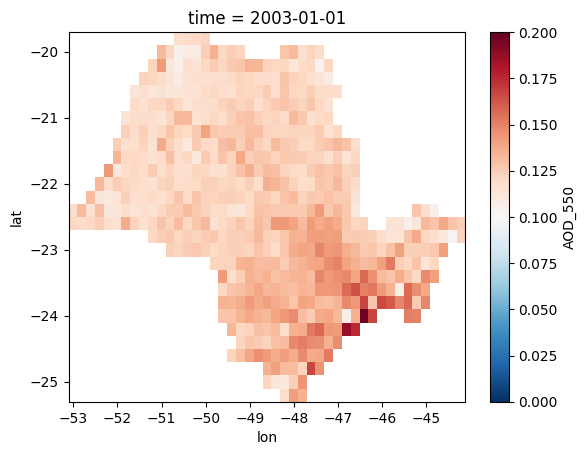

In [ ]:
ds.AOD_550.plot(cmap='RdBu_r', vmin=0, vmax=0.2)